# Mutual Fund Data Analysis (2022–2026)

## Exploratory Data Analysis (EDA)

### Objectives
- NAV Trend Analysis
- AUM Growth Analysis
- SIP Inflow Analysis
- Investor Demographics
- Geographic Distribution
- Folio Growth
- Sector Allocation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

# Display matplotlib plots in the notebook
%matplotlib inline

# Set default plotting style
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/mutual_fund_data.csv")

print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/mutual_fund_data.csv'

In [1]:
import os
print(os.getcwd())

C:\Users\sambh\Downloads\sambhavi\MutualFund_EDA_Project\notebooks


In [1]:
import os

print(os.getcwd())

C:\Users\sambh\Downloads\sambhavi\MutualFund_EDA_Project\notebooks


In [2]:
import os

print(os.listdir("../data/raw"))

['HDFC_Top100_NAV.csv']


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/HDFC_Top100_NAV.csv")

print(df.shape)
df.head()

(3109, 2)


,date,nav
0,25-06-2026,203.9157
1,24-06-2026,205.0655
2,23-06-2026,203.5443
3,22-06-2026,204.1263
4,19-06-2026,202.0761


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3109 entries, 0 to 3108
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3109 non-null   object 
 1   nav     3109 non-null   float64
dtypes: float64(1), object(1)
memory usage: 48.7+ KB


In [5]:
df.dtypes

date     object
nav     float64
dtype: object

In [6]:
df.isnull().sum()

date    0
nav     0
dtype: int64

In [7]:
df.describe()

,nav
count,3109.000000
mean,90.564076
std,60.719527
min,12.777500
25%,40.314300
50%,61.559500
75%,130.959100
max,214.676700


In [8]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df.dtypes

date    datetime64[ns]
nav            float64
dtype: object

In [9]:
df = df.sort_values("date")

df.head()

,date,nav
3108,2013-11-18,13.0894
3107,2013-11-19,13.1068
3106,2013-11-20,12.9549
3105,2013-11-21,12.7957
3104,2013-11-22,12.7775


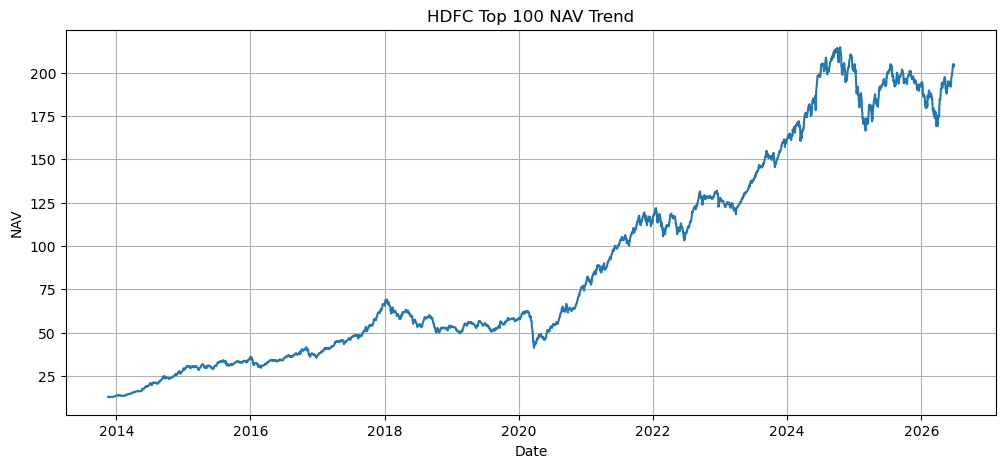

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["nav"])
plt.title("HDFC Top 100 NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

date    0
nav     0
dtype: int64

In [13]:
print("Minimum NAV:", df["nav"].min())
print("Maximum NAV:", df["nav"].max())

Minimum NAV: 12.7775
Maximum NAV: 214.6767


In [14]:
print(df.loc[df["nav"].idxmin()])
print(df.loc[df["nav"].idxmax()])

date    2013-11-22 00:00:00
nav                 12.7775
Name: 3104, dtype: object
date    2024-10-15 00:00:00
nav                214.6767
Name: 423, dtype: object


In [15]:
df["Daily_Return"] = df["nav"].pct_change() * 100

df.head()

,date,nav,Daily_Return
3108,2013-11-18,13.0894,NaN
3107,2013-11-19,13.1068,0.132932
3106,2013-11-20,12.9549,-1.158940
3105,2013-11-21,12.7957,-1.228879
3104,2013-11-22,12.7775,-0.142235


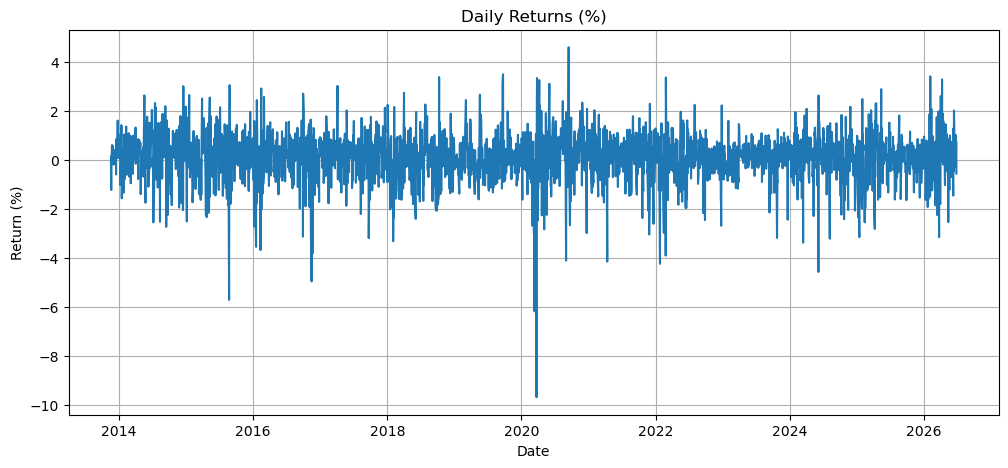

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["Daily_Return"])
plt.title("Daily Returns (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

In [17]:
df["MA_30"] = df["nav"].rolling(window=30).mean()

df.head()

,date,nav,Daily_Return,MA_30
3108,2013-11-18,13.0894,NaN,NaN
3107,2013-11-19,13.1068,0.132932,NaN
3106,2013-11-20,12.9549,-1.158940,NaN
3105,2013-11-21,12.7957,-1.228879,NaN
3104,2013-11-22,12.7775,-0.142235,NaN


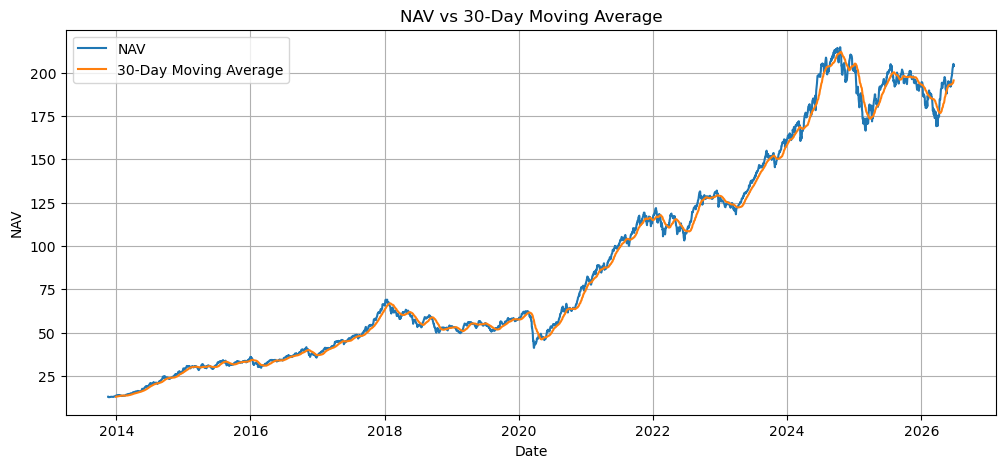

In [18]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["nav"], label="NAV")
plt.plot(df["date"], df["MA_30"], label="30-Day Moving Average")

plt.title("NAV vs 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
df.to_csv("../data/processed/processed_nav_data.csv", index=False)

print("Processed data saved successfully!")

Processed data saved successfully!


In [20]:
import os

print(os.listdir("../data/processed"))

['processed_nav_data.csv']


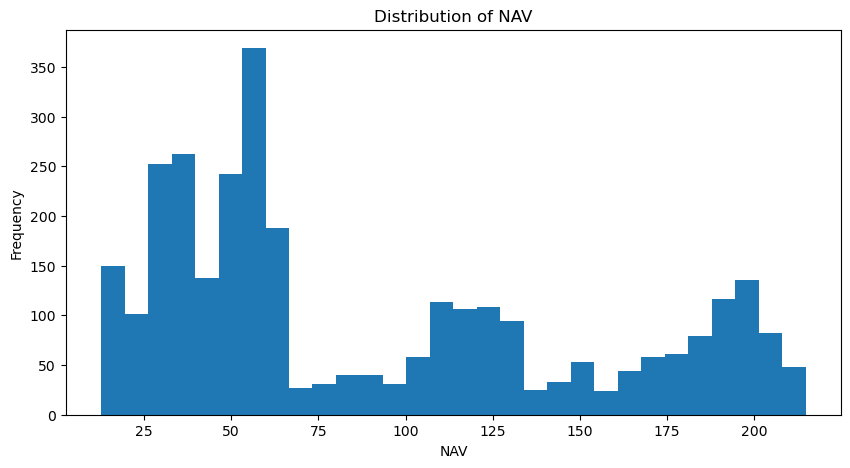

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["nav"], bins=30)

plt.title("Distribution of NAV")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.show()

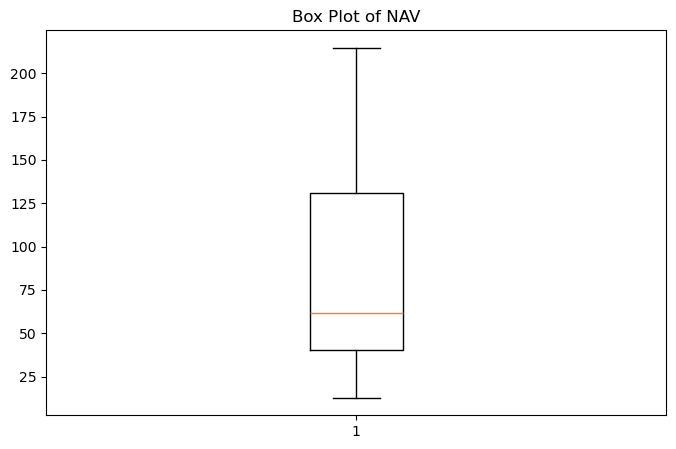

In [22]:
plt.figure(figsize=(8,5))

plt.boxplot(df["nav"])

plt.title("Box Plot of NAV")

plt.show()

In [23]:
df["Daily_Return"] = df["nav"].pct_change()*100

df.head()

,date,nav,Daily_Return,MA_30
3108,2013-11-18,13.0894,NaN,NaN
3107,2013-11-19,13.1068,0.132932,NaN
3106,2013-11-20,12.9549,-1.158940,NaN
3105,2013-11-21,12.7957,-1.228879,NaN
3104,2013-11-22,12.7775,-0.142235,NaN


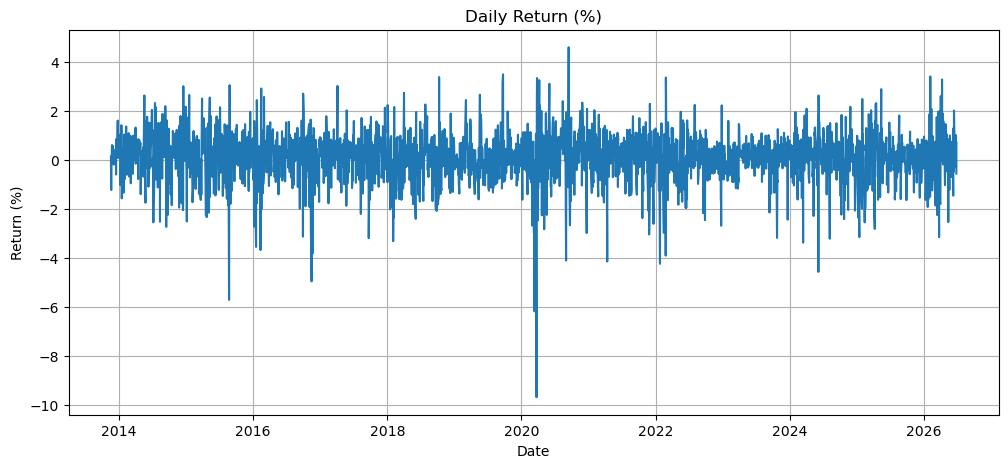

In [24]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["Daily_Return"])

plt.title("Daily Return (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")

plt.grid(True)

plt.show()

In [25]:
df["MA30"] = df["nav"].rolling(30).mean()

df.head()

,date,nav,Daily_Return,MA_30,MA30
3108,2013-11-18,13.0894,NaN,NaN,NaN
3107,2013-11-19,13.1068,0.132932,NaN,NaN
3106,2013-11-20,12.9549,-1.158940,NaN,NaN
3105,2013-11-21,12.7957,-1.228879,NaN,NaN
3104,2013-11-22,12.7775,-0.142235,NaN,NaN


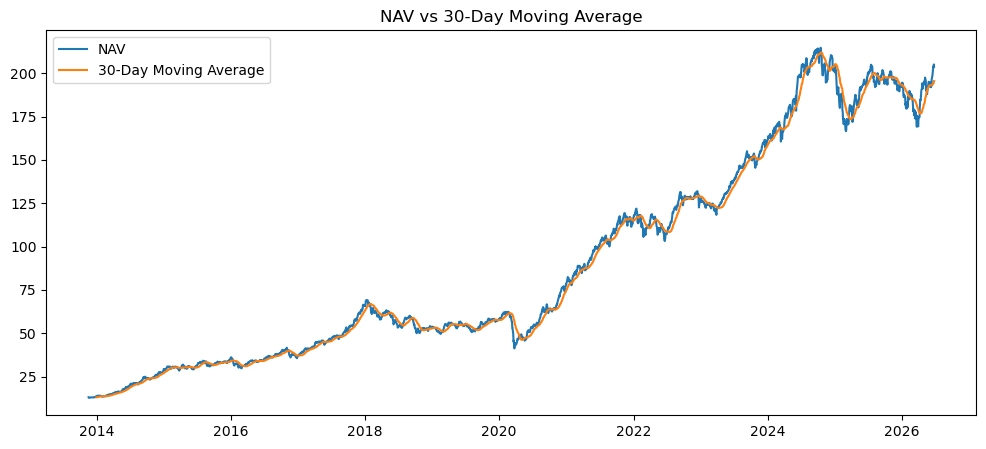

In [26]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["nav"], label="NAV")

plt.plot(df["date"], df["MA30"], label="30-Day Moving Average")

plt.legend()

plt.title("NAV vs 30-Day Moving Average")

plt.show()

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/processed/processed_nav_data.csv")

In [3]:
df.head()

,date,nav,Daily_Return,MA_30
0,2013-11-18,13.0894,NaN,NaN
1,2013-11-19,13.1068,0.132932,NaN
2,2013-11-20,12.9549,-1.158940,NaN
3,2013-11-21,12.7957,-1.228879,NaN
4,2013-11-22,12.7775,-0.142235,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3109 entries, 0 to 3108
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          3109 non-null   object 
 1   nav           3109 non-null   float64
 2   Daily_Return  3108 non-null   float64
 3   MA_30         3080 non-null   float64
dtypes: float64(3), object(1)
memory usage: 97.3+ KB


In [5]:
df.describe()

,nav,Daily_Return,MA_30
count,3109.000000,3108.000000,3080.000000
mean,90.564076,0.092997,90.423561
std,60.719527,0.957439,60.267616
min,12.777500,-9.696416,13.054460
25%,40.314300,-0.334034,39.966529
50%,61.559500,0.150200,60.955152
75%,130.959100,0.626285,129.076022
max,214.676700,4.602583,211.959193


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/processed_nav_data.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,nav,Daily_Return,MA_30
0,2013-11-18,13.0894,NaN,NaN
1,2013-11-19,13.1068,0.132932,NaN
2,2013-11-20,12.9549,-1.158940,NaN
3,2013-11-21,12.7957,-1.228879,NaN
4,2013-11-22,12.7775,-0.142235,NaN


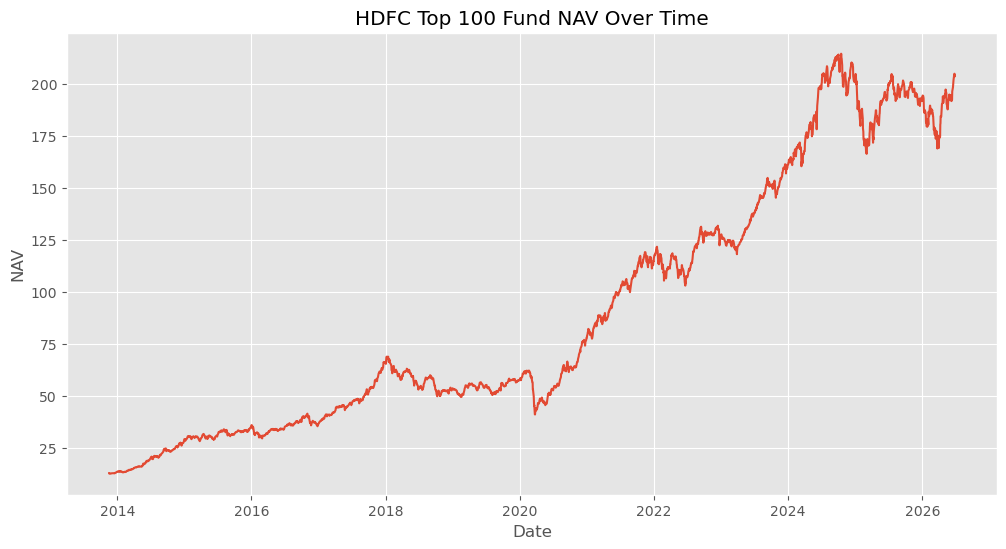

In [3]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["nav"])

plt.title("HDFC Top 100 Fund NAV Over Time")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

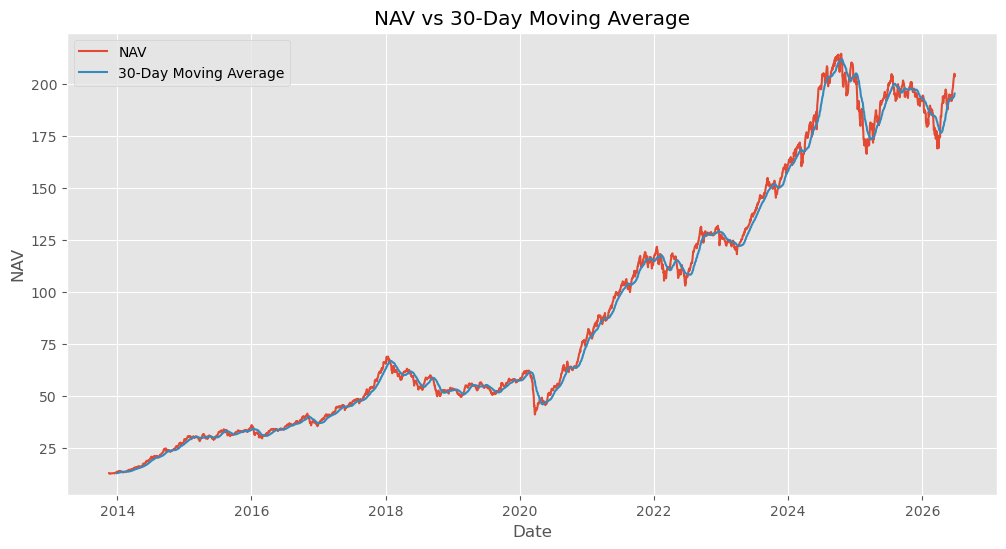

In [4]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["nav"], label="NAV")
plt.plot(df["date"], df["MA_30"], label="30-Day Moving Average")

plt.title("NAV vs 30-Day Moving Average")

plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.show()

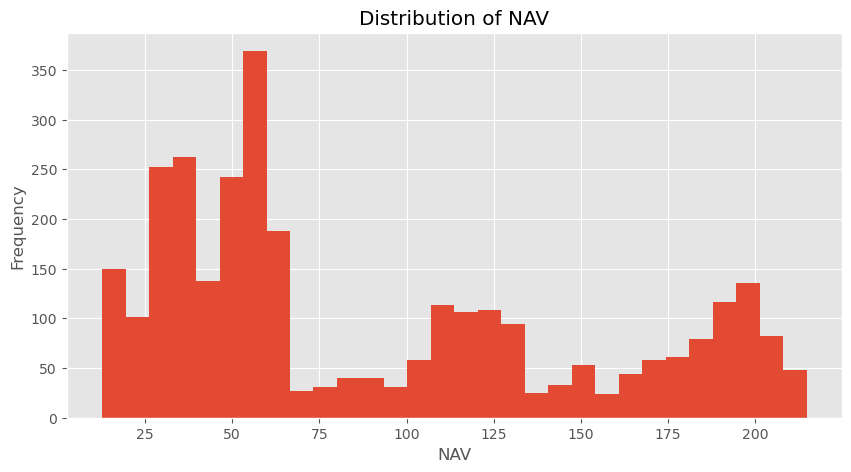

In [5]:
plt.figure(figsize=(10,5))

plt.hist(df["nav"], bins=30)

plt.title("Distribution of NAV")

plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.show()

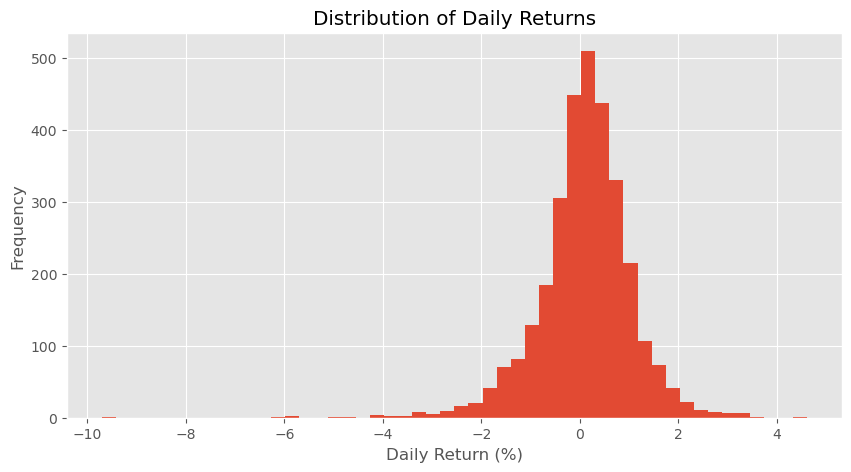

In [6]:
plt.figure(figsize=(10,5))

plt.hist(df["Daily_Return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

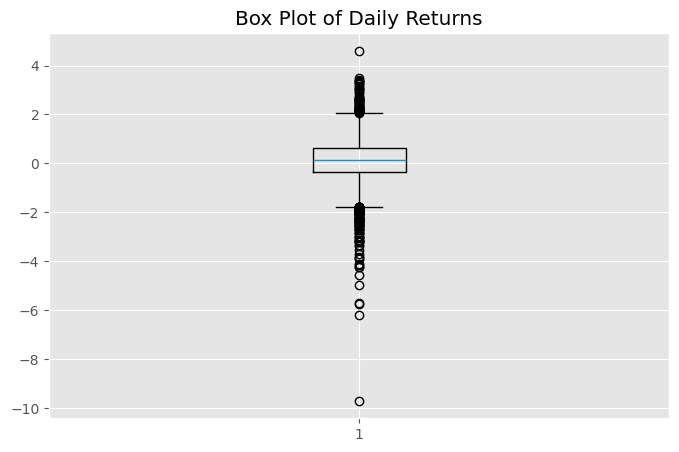

In [7]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Daily_Return"].dropna())

plt.title("Box Plot of Daily Returns")

plt.show()

In [8]:
print(df[["nav", "MA_30"]].corr())

            nav     MA_30
nav    1.000000  0.998305
MA_30  0.998305  1.000000
